# Exploration des données Vélib' — PFE

Ce notebook se connecte à la base PostgreSQL du projet, charge l'historique
collecté dans la couche **silver** (dbt), et explore les patterns de
disponibilité des vélos : évolution dans le temps, par heure de la journée,
par jour de la semaine, par station.

Objectif : comprendre les données avant de construire les features pour le
modèle de prédiction.

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_URL = (
    f"postgresql+psycopg2://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)
engine = create_engine(DB_URL)
print("Connexion OK ->", DB_URL.split('@')[1])

Connexion OK -> localhost:5432/velib_dw


## 1. Chargement des données

In [10]:
# On charge l'historique de statut des stations (couche silver = nettoyée)
query_status = """
    select station_id, collected_at, num_bikes_available, num_docks_available
    from dbt_dev.silver_station_status
    order by collected_at
"""
df_status = pd.read_sql(query_status, engine, parse_dates=["collected_at"])
print(f"{len(df_status):,} lignes chargées")
df_status.head()

37,881 lignes chargées


,station_id,collected_at,num_bikes_available,num_docks_available
0,19016646124,2026-09-21 23:06:06.633491+00:00,12,14
1,1074204954,2026-09-21 23:06:06.633491+00:00,28,2
2,221047138,2026-09-21 23:06:06.633491+00:00,4,14
3,84966359,2026-09-21 23:06:06.633491+00:00,3,23
4,34836174,2026-09-21 23:06:06.633491+00:00,15,17


In [11]:
# Infos statiques des stations (nom, position, capacité)
query_info = """
    select station_id, name, lat, lon, capacity
    from dbt_dev.silver_station_information
"""
df_info = pd.read_sql(query_info, engine)
print(f"{len(df_info):,} stations")
df_info.head()

1,518 stations


,station_id,name,lat,lon,capacity
0,1002059045,Pont Neuf - Rivoli,48.860090,2.344058,27
1,100227241,Guynemer - Jardin du Luxembourg,48.846613,2.332548,36
2,1002738770,Lavandieres Sainte Opportune - Rivoli,48.859280,2.346622,27
3,100759356,Montmartre - Etienne Marcel,48.865022,2.345068,16
4,100760396,Turbigo - Réaumur,48.865574,2.356420,31


## 2. Vue d'ensemble

Combien de temps d'historique on a, et combien de "snapshots" (une collecte = un
instant T pour toutes les stations).

In [12]:
print("Première collecte :", df_status['collected_at'].min())
print("Dernière collecte :", df_status['collected_at'].max())
print("Nombre de collectes distinctes :", df_status['collected_at'].nunique())
print("Nombre de stations :", df_status['station_id'].nunique())

Première collecte : 2026-09-21 23:06:06.633491+00:00
Dernière collecte : 2026-09-22 19:09:39.712433+00:00
Nombre de collectes distinctes : 25
Nombre de stations : 1516


## 3. Disponibilité moyenne dans le temps (toutes stations confondues)

Ce graphique montre la moyenne du nombre de vélos disponibles à chaque instant
de collecte. S'il n'y a que quelques heures de données, la tendance sera
courte — mais la courbe se remplira au fur et à mesure que la collecte
continue en arrière-plan (le conteneur Docker `ingestion` tourne en continu).

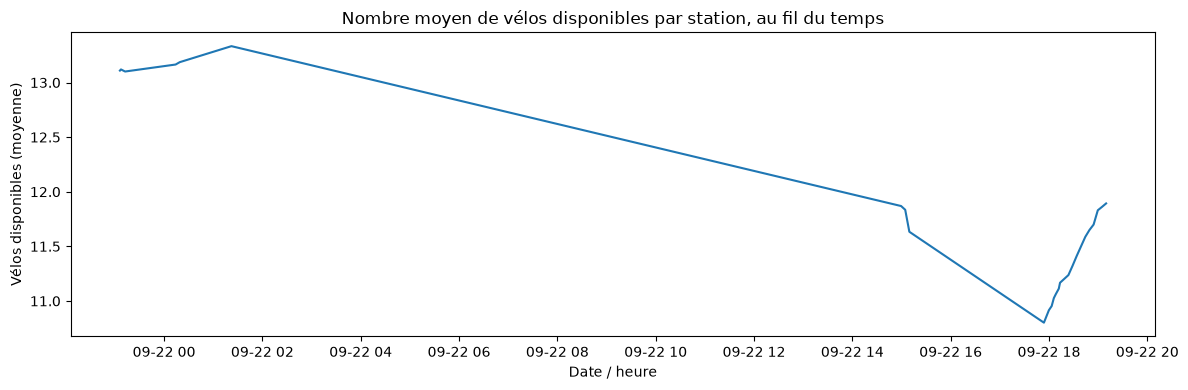

In [16]:
avg_over_time = df_status.groupby("collected_at")["num_bikes_available"].mean()

plt.figure(figsize=(12, 4))
plt.plot(avg_over_time.index, avg_over_time.values)
plt.title("Nombre moyen de vélos disponibles par station, au fil du temps")
plt.xlabel("Date / heure")
plt.ylabel("Vélos disponibles (moyenne)")
plt.tight_layout()
plt.show()

## 4. Pattern par heure de la journée

C'est LE pattern clé pour la prédiction : les stations se vident/remplissent
selon l'heure (heures de pointe, nuit, etc). Plus on aura de jours
d'historique, plus cette courbe sera fiable.

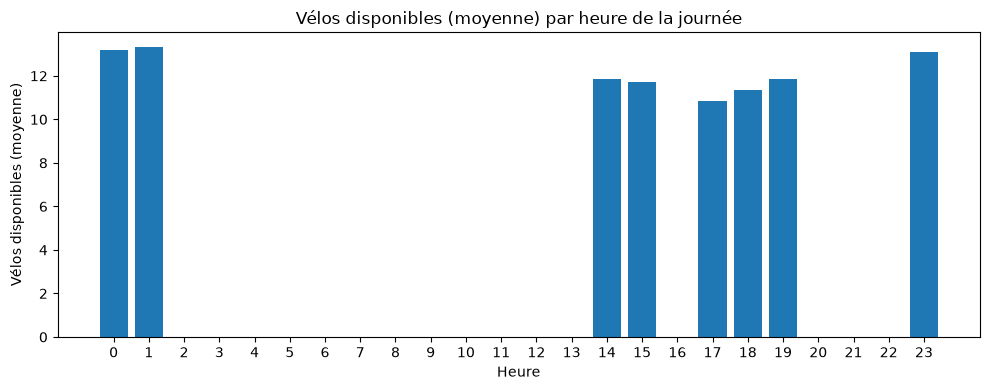

In [14]:
df_status["hour"] = df_status["collected_at"].dt.hour

avg_by_hour = df_status.groupby("hour")["num_bikes_available"].mean()

plt.figure(figsize=(10, 4))
plt.bar(avg_by_hour.index, avg_by_hour.values)
plt.title("Vélos disponibles (moyenne) par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Vélos disponibles (moyenne)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 5. Zoom sur quelques stations

Comparaison de l'évolution de 3 stations différentes (ex: gare, résidentiel,
touristique) pour voir si elles ont des comportements différents.

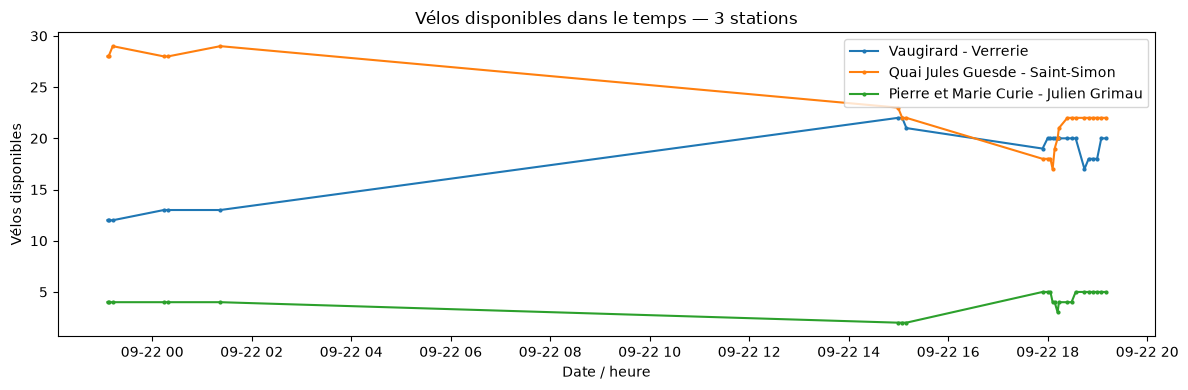

In [15]:
sample_stations = df_status["station_id"].drop_duplicates().head(3).tolist()

plt.figure(figsize=(12, 4))
for sid in sample_stations:
    sub = df_status[df_status["station_id"] == sid]
    name = df_info.loc[df_info["station_id"] == sid, "name"].values
    label = name[0] if len(name) else sid
    plt.plot(sub["collected_at"], sub["num_bikes_available"], label=label, marker="o", markersize=2)

plt.title("Vélos disponibles dans le temps — 3 stations")
plt.xlabel("Date / heure")
plt.ylabel("Vélos disponibles")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Prochaine étape : feature engineering

Une fois qu'on a assez d'historique (idéalement plusieurs jours), on
transformera ces données en variables ("features") pour le modèle :

- `hour`, `day_of_week` (déjà vu ci-dessus que ça a un effet)
- `lag_15min`, `lag_30min`, `lag_1h` : combien de vélos il y a 15/30/60 min
- `trend` : la station se vide ou se remplit (dérivée)
- météo (optionnel, via Open-Meteo)

Ce sera fait dans un prochain notebook / script, une fois qu'on aura
suffisamment d'historique accumulé par la collecte continue.